In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r'C:\kdt_0900_ojh\ml\resource\dataset'
file_name = r'titanic.csv'
file_path = os.path.join(base_path, file_name)

In [3]:
df = pd.read_csv(file_path)
df.head(5)

# - 타이타닉 데이터셋 입력 컬럼(Feature) 상세 설명

# | 컬럼명 | 설명 및 의미 | 비고 / 값 예시 |
# | pclass | 객실 등급 (Ticket class) | 1 = 1등석, 2 = 2등석, 3 = 3등석 |
# | sex | 성별 | male (남성), female (여성) |
# | age | 나이 | 결측치 존재, 1세 미만은 소수점 표시 |
# | sibsp | 동승한 형제/자매/배우자의 수 | 0, 1, 2 ... |
# | parch | 동승한 부모/자녀의 수 | 0, 1, 2 ... |
# | fare | 탑승 요금 | 승객이 지불한 운임 (파운드화) |
# | embarked | 탑승 항구 코드 | C = Cherbourg, Q = Queenstown, S = Southampton |
# | class | 객실 등급 텍스트 | First, Second, Third (pclass와 동일 정보) |
# | who | 승객 구분 | man (성인 남성), woman (성인 여성), child (아이) |
# | deck | 선실 구역 번호 | A, B, C, D, E, F, G (결측치 매우 많음) |
# | embark_town | 탑승 도시 이름 | Cherbourg, Queenstown, Southampton |
# | alone | 혼자 탑승했는지 여부 | True (동승자 없음), False (동승자 있음) |

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
columns_drop = ['PassengerId','Name','Ticket','Cabin','Embarked']
titanic_df = df.drop(columns_drop, axis=1)

In [5]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [7]:
titanic_df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Age'>

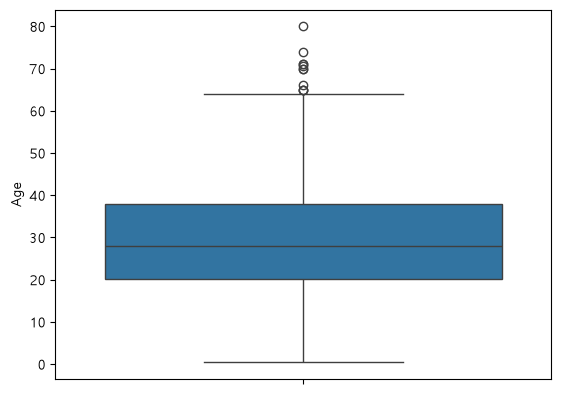

In [8]:
sns.boxplot(titanic_df['Age'])

In [9]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Age'] = titanic_df['Age'].astype(int)

In [10]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


In [11]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.345679,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.028212,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male':0, 'female':1})

In [13]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(6)
memory usage: 48.9 KB


In [16]:
titanic_df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.345679,0.523008,0.381594,32.204208
std,0.486592,0.836071,0.477990,13.028212,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
corr_matrix = titanic_df.corr(numeric_only=True)

<Axes: >

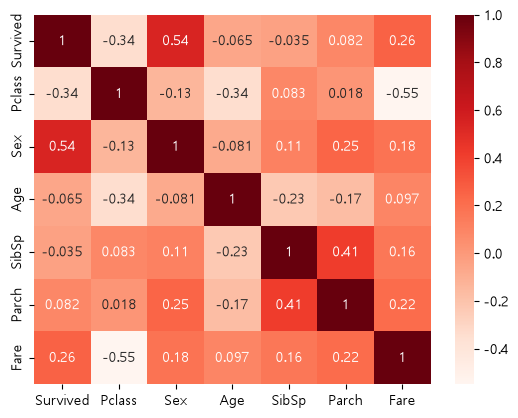

In [15]:
sns.heatmap(corr_matrix, cmap='Reds', annot=True)

In [19]:
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y)

In [22]:
scaler = StandardScaler()

In [23]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
for i in [0.001, 0.01, 0.05, 0.1, 1]:
    lr = LogisticRegression(C=i)
    lr.fit(X_train_scaled, y_train)
    trained_score = lr.score(X_train_scaled, y_train)
    tested_score = lr.score(X_test_scaled, y_test)
    print(i,trained_score)
    print(i,tested_score)

0.001 0.6530898876404494
0.001 0.6480446927374302
0.01 0.8160112359550562
0.01 0.776536312849162
0.05 0.8061797752808989
0.05 0.7877094972067039
0.1 0.800561797752809
0.1 0.7932960893854749
1 0.7935393258426966
1 0.7988826815642458


In [36]:
y_pred = lr.predict(X_test_scaled)

In [44]:
recall_score(y_test, y_pred)

0.7101449275362319

In [40]:
f1_score(y_true = y_test, y_pred = y_pred)

0.7313432835820896

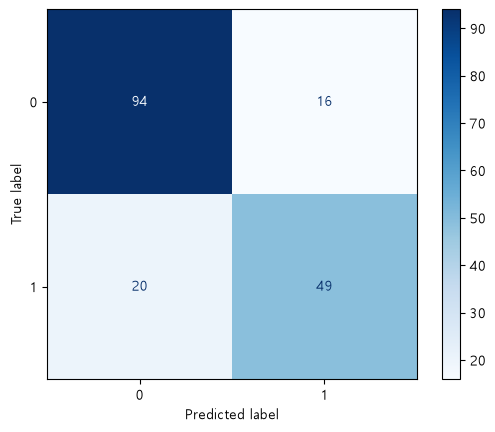

In [48]:
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test,
    cmap='Blues'
)